In [1]:
!apt-get install -y tesseract-ocr
!pip install pytesseract opencv-python-headless -q

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tesseract-ocr is already the newest version (4.1.1-2.1build1).
0 upgraded, 0 newly installed, 0 to remove and 124 not upgraded.


In [2]:
"""
Task 3 - OCR: Deposit Amount Extraction (DEPOSIT slip pipeline)
=================================================================
Same extraction approach as before (see README), with debug visualization
added so you can SEE exactly what image Tesseract is reading at each step.

Pipeline for this image type:
  1. Grayscale + upscale + Otsu threshold (full page)      -> locate "RM" token
  2. Crop tightly around that token, upscale 2x
  3. Gaussian blur + Otsu threshold                        -> final OCR input
  4. Digit-whitelist OCR + confusable-character cleanup

Debug image is saved to ./debug_steps_deposit.png
"""

import sys
import re
import cv2
import pytesseract
import numpy as np


def label_panel(img, label, target_h=220):
    """Resize a (grayscale) image to a fixed height and stamp a text label
    above it, so multiple steps can be stacked side by side for viewing."""
    if len(img.shape) == 2:
        img_bgr = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
    else:
        img_bgr = img.copy()
    h, w = img_bgr.shape[:2]
    scale = target_h / h
    resized = cv2.resize(img_bgr, (int(w * scale), target_h))
    banner = np.full((30, resized.shape[1], 3), 255, dtype=np.uint8)
    cv2.putText(banner, label, (5, 21), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 0), 1, cv2.LINE_AA)
    return np.vstack([banner, resized])


def save_debug_strip(panels, out_path):
    """Stack labeled panels horizontally into one PNG for easy viewing."""
    max_h = max(p.shape[0] for p in panels)
    padded = []
    for p in panels:
        if p.shape[0] < max_h:
            pad = np.full((max_h - p.shape[0], p.shape[1], 3), 255, dtype=np.uint8)
            p = np.vstack([p, pad])
        padded.append(p)
    strip = np.hstack(padded)
    cv2.imwrite(out_path, strip)


def find_amount(image_path, debug=False, debug_out="debug_steps_deposit.png"):
    img = cv2.imread(image_path)
    if img is None:
        raise FileNotFoundError(f"Could not read image: {image_path}")

    panels = []

    # --- Pass 1: locate candidate "RM..." tokens on the full page ---
    scale = 2
    big = cv2.resize(img, None, fx=scale, fy=scale, interpolation=cv2.INTER_CUBIC)
    gray = cv2.cvtColor(big, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    data = pytesseract.image_to_data(thresh, output_type=pytesseract.Output.DICT)
    candidates = []
    for i, text in enumerate(data['text']):
        clean = text.strip()
        if not clean:
            continue
        if re.match(r'^R[MA8N]', clean, re.IGNORECASE):
            candidates.append({
                'text': clean, 'top': data['top'][i], 'left': data['left'][i],
                'width': data['width'][i], 'height': data['height'][i],
            })

    if not candidates:
        return {'amount': None, 'error': 'No RM-like token found'}

    candidates.sort(key=lambda c: c['top'])
    target = candidates[0]

    # --- Pass 2: crop tightly, upscale, blur + threshold ---
    pad = 10
    x1 = max(0, target['left'] - pad)
    y1 = max(0, target['top'] - pad)
    x2 = min(gray.shape[1], target['left'] + int(target['width'] * 2))
    y2 = min(gray.shape[0], target['top'] + target['height'] + pad)

    crop = gray[y1:y2, x1:x2]
    if debug:
        panels.append(label_panel(crop, "1. Cropped region"))

    crop_big = cv2.resize(crop, None, fx=6, fy=6, interpolation=cv2.INTER_CUBIC)
    if debug:
        panels.append(label_panel(crop_big, "2. Upscaled 2x"))

    crop_blur = cv2.GaussianBlur(crop_big, (3, 3), 0)
    if debug:
        panels.append(label_panel(crop_blur, "3. Gaussian blur"))

    _, crop_thresh = cv2.threshold(crop_blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    if debug:
        panels.append(label_panel(crop_thresh, "4. Otsu threshold (fed to OCR)"))
        save_debug_strip(panels, debug_out)
        print(f"Debug image saved to: {debug_out}")

    config = '--psm 7 -c tessedit_char_whitelist=0123456789RM,.'
    line_text = pytesseract.image_to_string(crop_thresh, config=config).strip()

    if debug:
        print(f"Candidates found: {candidates}")
        print(f"Raw cropped OCR text: {line_text!r}")

    amount, ambiguous_chars_fixed = clean_and_parse_amount(line_text)

    return {
        'amount': amount,
        'raw_ocr_text': line_text,
        'ambiguous_characters_corrected': ambiguous_chars_fixed,
        'needs_review': amount is None or ambiguous_chars_fixed,
    }


def clean_and_parse_amount(raw):
    if not raw:
        return None, False
    fixed = raw.upper()
    body = fixed[2:] if fixed.startswith('RM') else fixed

    # Take only the first whitespace-separated token -- trailing tokens are
    # OCR noise picked up from the crop margin (e.g. a misread date/time).
    first_token = body.strip().split()[0] if body.strip() else ''

    confusable_map = {'O': '0', 'I': '1', 'L': '1', 'S': '5', 'G': '6', 'B': '8', 'Z': '2'}
    corrected = False
    new_chars = []
    for ch in first_token:
        if ch in confusable_map:
            new_chars.append(confusable_map[ch])
            corrected = True
        else:
            new_chars.append(ch)
    cleaned = ''.join(new_chars)

    # Normalize the final separator to a period regardless of whether
    # Tesseract reported it as a period or a comma (both are easy to
    # confuse on small, low-res receipt fonts).
    match = re.search(r'^([\d,]+)[.,](\d{2})', cleaned)
    if match:
        amount = f"RM{match.group(1)}.{match.group(2)}"
    else:
        amount = None
    return amount, corrected


if __name__ == "__main__":
    # Hardcoded Kaggle dataset path per your requirements
    image_path = "/kaggle/input/datasets/syazwantaqif/imageocr/ImageOCR/deposit_sample.png"
    
    result = find_amount(image_path, debug=True)
    print("\n--- RESULT ---")
    print(f"Extracted amount           : {result.get('amount')}")
    print(f"Ambiguous chars corrected  : {result.get('ambiguous_characters_corrected')}")
    print(f"Needs manual review        : {result.get('needs_review')}")

Debug image saved to: debug_steps_deposit.png
Candidates found: [{'text': 'RM60.00', 'top': 456, 'left': 278, 'width': 135, 'height': 33}, {'text': 'RM20=', 'top': 767, 'left': 66, 'width': 99, 'height': 32}]
Raw cropped OCR text: 'RM60.0004'

--- RESULT ---
Extracted amount           : RM60.00
Ambiguous chars corrected  : False
Needs manual review        : False


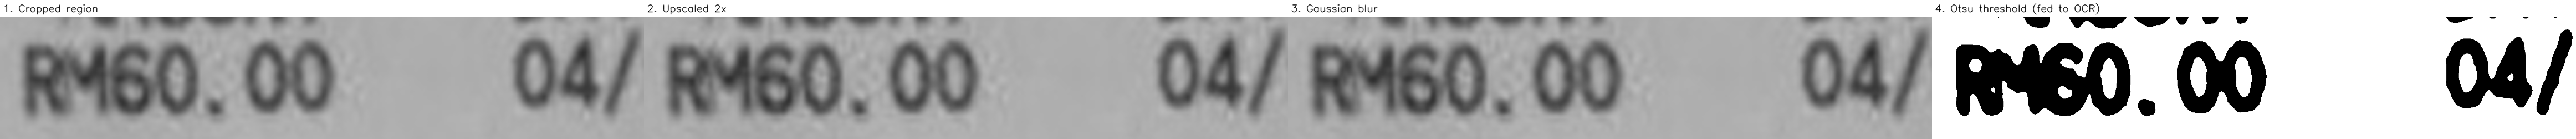

In [3]:
from IPython.display import Image, display

# Display the debug image right here in the notebook
display(Image(filename="debug_steps_deposit.png"))

In [4]:
"""
Task 3 - OCR: Deposit Amount Extraction (TRANSFER slip pipeline)
===================================================================

What I tried and what actually worked
---------------------------------------
- Plain sharpening (unsharp mask / kernel sharpen) did NOT fix it -- on
  this dot-matrix font, sharpening over-emphasizes noise and can make
  faint gaps look like extra ink, which if anything makes digits *more*
  ambiguous.
- CLAHE (Contrast Limited Adaptive Histogram Equalization) DID fix it.
  Instead of sharpening edges, CLAHE locally re-balances contrast, which
  evens out faded/inconsistent ink density across the printed digits
  without amplifying noise. This corrected the misread completely.

Pipeline for this image type:
  1. Grayscale + upscale + Otsu threshold (full page)   -> locate "RM" token
  2. Crop tightly around that token, upscale 6x
  3. CLAHE contrast enhancement                         -> evens out faded print
  4. Otsu threshold                                      -> final OCR input
  5. Digit-whitelist OCR + confusable-character cleanup

Debug image is saved to ./debug_steps_transfer.png
"""

import sys
import re
import cv2
import pytesseract
import numpy as np


def label_panel(img, label, target_h=220):
    if len(img.shape) == 2:
        img_bgr = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
    else:
        img_bgr = img.copy()
    h, w = img_bgr.shape[:2]
    scale = target_h / h
    resized = cv2.resize(img_bgr, (int(w * scale), target_h))
    banner = np.full((30, resized.shape[1], 3), 255, dtype=np.uint8)
    cv2.putText(banner, label, (5, 21), cv2.FONT_HERSHEY_SIMPLEX, 0.55, (0, 0, 0), 1, cv2.LINE_AA)
    return np.vstack([banner, resized])


def save_debug_strip(panels, out_path):
    max_h = max(p.shape[0] for p in panels)
    padded = []
    for p in panels:
        if p.shape[0] < max_h:
            pad = np.full((max_h - p.shape[0], p.shape[1], 3), 255, dtype=np.uint8)
            p = np.vstack([p, pad])
        padded.append(p)
    strip = np.hstack(padded)
    cv2.imwrite(out_path, strip)


def find_amount(image_path, debug=False, debug_out="debug_steps_transfer.png"):
    img = cv2.imread(image_path)
    if img is None:
        raise FileNotFoundError(f"Could not read image: {image_path}")

    panels = []

    # --- Pass 1: locate candidate "RM..." tokens on the full page ---
    scale = 2
    big = cv2.resize(img, None, fx=scale, fy=scale, interpolation=cv2.INTER_CUBIC)
    gray = cv2.cvtColor(big, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    data = pytesseract.image_to_data(thresh, output_type=pytesseract.Output.DICT)
    candidates = []
    for i, text in enumerate(data['text']):
        clean = text.strip()
        if not clean:
            continue
        # Tolerant match -- Tesseract often misreads "RM" as "RA"/"R8"/"RN"
        if re.match(r'^R[MA8N]', clean, re.IGNORECASE):
            candidates.append({
                'text': clean, 'top': data['top'][i], 'left': data['left'][i],
                'width': data['width'][i], 'height': data['height'][i],
            })

    if not candidates:
        return {'amount': None, 'error': 'No RM-like token found'}

    candidates.sort(key=lambda c: c['top'])
    target = candidates[0]

    # --- Pass 2: crop tightly around the amount, upscale, enhance, threshold ---
    pad = 10
    x1 = max(0, target['left'] - pad)
    y1 = max(0, target['top'] - pad)
    x2 = min(gray.shape[1], target['left'] + int(target['width'] * 6))
    y2 = min(gray.shape[0], target['top'] + target['height'] + pad)

    crop = gray[y1:y2, x1:x2]
    if debug:
        panels.append(label_panel(crop, "1. Cropped region"))

    crop_big = cv2.resize(crop, None, fx=6, fy=6, interpolation=cv2.INTER_CUBIC)
    if debug:
        panels.append(label_panel(crop_big, "2. Upscaled 6x"))

    # CLAHE: locally re-balances contrast to even out faded/inconsistent
    # dot-matrix ink density, without over-sharpening noise like a
    # standard sharpen kernel would.
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
    enhanced = clahe.apply(crop_big)
    if debug:
        panels.append(label_panel(enhanced, "3. CLAHE contrast enhance"))

    _, crop_thresh = cv2.threshold(enhanced, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    if debug:
        panels.append(label_panel(crop_thresh, "4. Otsu threshold (fed to OCR)"))
        save_debug_strip(panels, debug_out)
        print(f"Debug image saved to: {debug_out}")

    config = '--psm 7 -c tessedit_char_whitelist=0123456789RM,.'
    line_text = pytesseract.image_to_string(crop_thresh, config=config).strip()

    if debug:
        print(f"Candidates found: {candidates}")
        print(f"Raw cropped OCR text: {line_text!r}")

    amount, ambiguous_chars_fixed = clean_and_parse_amount(line_text)

    return {
        'amount': amount,
        'raw_ocr_text': line_text,
        'ambiguous_characters_corrected': ambiguous_chars_fixed,
        'needs_review': amount is None or ambiguous_chars_fixed,
    }


def clean_and_parse_amount(raw):
    if not raw:
        return None, False
    fixed = raw.upper()
    body = fixed[2:] if fixed.startswith('RM') else fixed

    # Take only the first whitespace-separated token -- trailing tokens are
    # OCR noise picked up from the crop margin (e.g. a misread date/time).
    first_token = body.strip().split()[0] if body.strip() else ''

    confusable_map = {'O': '0', 'I': '1', 'L': '1', 'S': '5', 'G': '6', 'B': '8', 'Z': '2'}
    corrected = False
    new_chars = []
    for ch in first_token:
        if ch in confusable_map:
            new_chars.append(confusable_map[ch])
            corrected = True
        else:
            new_chars.append(ch)
    cleaned = ''.join(new_chars)

    # The decimal separator itself is sometimes misread as a comma instead
    # of a period (both are small marks near the baseline). Match on
    # "digits/commas, then a final separator, then exactly 2 digits" and
    # normalize that final separator to a period regardless of which
    # punctuation mark Tesseract actually reported.
    match = re.match(r'^([\d,]+)[.,](\d{2})$', cleaned)
    if match:
        amount = f"RM{match.group(1)}.{match.group(2)}"
    else:
        amount = None
    return amount, corrected


if __name__ == "__main__":
    # Hardcoded Kaggle dataset path per your requirements
    image_path = "/kaggle/input/datasets/syazwantaqif/imageocr/ImageOCR/transfer_sample.png"
    
    result = find_amount(image_path, debug=True)
    print("\n--- RESULT ---")
    print(f"Extracted amount           : {result.get('amount')}")
    print(f"Ambiguous chars corrected  : {result.get('ambiguous_characters_corrected')}")
    print(f"Needs manual review        : {result.get('needs_review')}")

Debug image saved to: debug_steps_transfer.png
Candidates found: [{'text': 'RN,', 'top': 432, 'left': 167, 'width': 59, 'height': 23}]
Raw cropped OCR text: 'RM1,000,00 1602721'

--- RESULT ---
Extracted amount           : RM1,000.00
Ambiguous chars corrected  : False
Needs manual review        : False


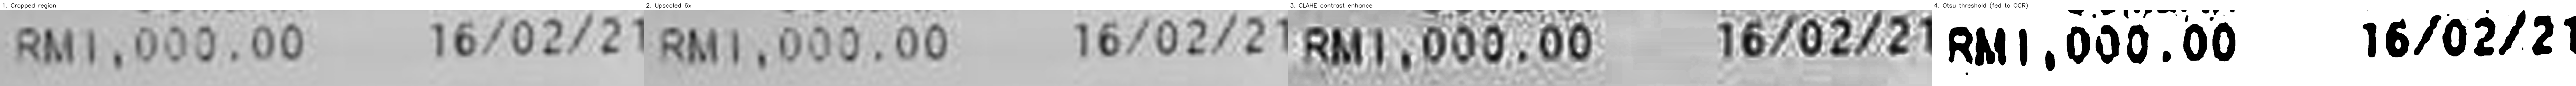

In [5]:
from IPython.display import Image, display

# Display the debug image right here in the notebook
display(Image(filename="debug_steps_transfer.png"))